<a href="https://colab.research.google.com/github/AngelGarcia0905/IA/blob/main/Redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Celda 0: Librerías
import sys  # Acceso a versiones de Python
import platform  # Información de la arquitectura del sistema
import psutil  # Métricas de memoria RAM y CPU
import os  # Interfaz con el sistema operativo
import pandas as pd  # Librería para manipulación de tablas
import numpy as np  # Librería para operaciones matemáticas
import matplotlib.pyplot as plt  # Librería para crear gráficas

In [ ]:
#Celda 1 Celda de verificación de hardware y entorno
print(f"--- REPORTE DE EJECUCIÓN ---")  # Título del encabezado
print(f"Python Version: {sys.version.split()[0]}")  # Muestra versión de Python (ej. 3.10)
print(f"Plataforma: {platform.system()} {platform.release()}")  # Indica si es Linux (Colab) o Windows
print(f"Procesador: {platform.processor() or 'Genérico'}")  # Tipo de CPU detectada
print(f"RAM Total: {psutil.virtual_memory().total / 1e9:.2f} GB")  # Memoria RAM disponible en GB
print(f"Núcleos CPU: {os.cpu_count()}")  # Cantidad de núcleos de procesamiento

# Verificación de GPU (Vital para Redes Neuronales)
try:  # Bloque de prueba por si no hay GPU activada
    from tensorflow.python.client import device_lib  # Herramienta de detección de hardware
    devices = device_lib.list_local_devices()  # Lista dispositivos disponibles
    gpu_info = [d.physical_device_desc for d in devices if d.device_type == 'GPU']  # Filtra por GPU
    print(f"GPU: {gpu_info[0] if gpu_info else 'No asignada'}")  # Muestra modelo (ej. Tesla T4)
except:  # En caso de error en la librería
    print("GPU: Error en detección")  # Aviso de falla técnica

--- REPORTE DE EJECUCIÓN ---
Python Version: 3.12.12
Plataforma: Linux 6.6.113+
Procesador: x86_64
RAM Total: 13.61 GB
Núcleos CPU: 2
GPU: device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [ ]:
#Celda 2 Carga y Exploración de Datos
url = "https://raw.githubusercontent.com/dilp90/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/main/MachineLearning/Datasets/robot_sensors.csv"
df = pd.read_csv(url)  # Descarga y lee el archivo CSV
print("--- Primeras filas del Dataset ---")  # Encabezado para la consola
print(df.head())  # Muestra los primeros 5 registros

--- Primeras filas del Dataset ---
   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0       43.708611          9.256646         23.925585
1           1       95.564288         27.095047         23.704682
2           2       75.879455         43.647292         33.593819
3           3       63.879264         36.611244         23.743193
4           4       24.041678         40.328057         24.079246


In [ ]:
#Celda 3 Eliminación de nulos y valores fuera de rango
df_limpio = df.dropna().copy()  # Elimina filas con valores nulos
df_limpio = df_limpio[df_limpio['Velocidad (cm/s)'] >= 0]  # Filtra velocidades negativas erróneas
print(f"Registros originales: {len(df)}")  # Imprime conteo inicial
print(f"Registros tras limpieza: {len(df_limpio)}")  # Imprime conteo final

Registros originales: 1000
Registros tras limpieza: 913


In [ ]:
#Celda 4 Escalamiento Min-Max para Redes Neuronales
cols = ['Distancia (cm)', 'Velocidad (cm/s)', 'Temperatura (°C)']  # Columnas a normalizar
df_norm = df_limpio.copy()  # Copia los datos para no alterar los limpios

for c in cols:  # Inicia ciclo para cada sensor
    val_min = df_norm[c].min()  # Obtiene el valor mínimo de la columna
    val_max = df_norm[c].max()  # Obtiene el valor máximo de la columna
    df_norm[c] = (df_norm[c] - val_min) / (val_max - val_min)  # Aplica escala de 0 a 1

print("Visualización de datos normalizados (0-1):")  # Mensaje de éxito
print(df_norm.head())  # Muestra los nuevos valores escalados

Visualización de datos normalizados (0-1):
   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0        0.371735          0.182609          0.262269
1           1        0.950755          0.540740          0.247509
2           2        0.730954          0.873049          0.908233
3           3        0.596960          0.731791          0.250082
4           4        0.152134          0.806411          0.272535


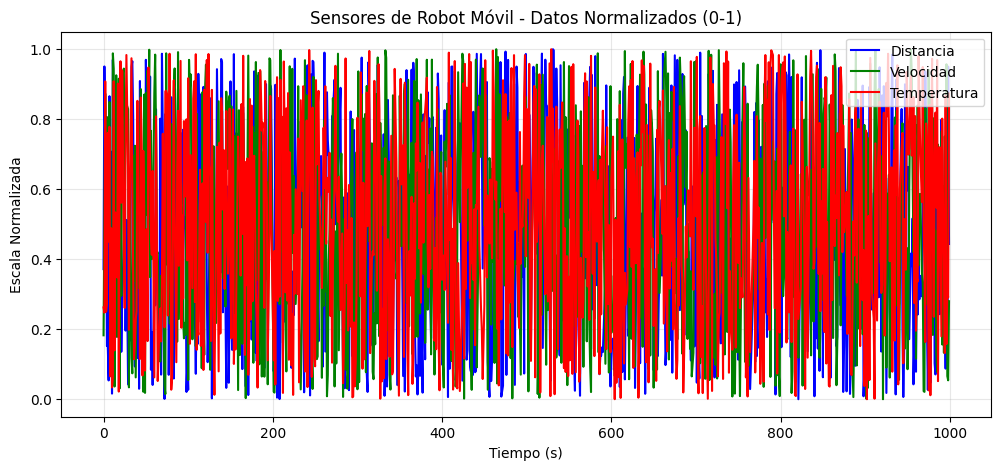

In [ ]:
#Celda 5 Generación de gráfico comparativo de sensores
plt.figure(figsize=(12, 5))  # Configura el tamaño de la imagen
plt.plot(df_norm['Tiempo (s)'], df_norm['Distancia (cm)'], label='Distancia', color='b')  # Gráfica azul
plt.plot(df_norm['Tiempo (s)'], df_norm['Velocidad (cm/s)'], label='Velocidad', color='g')  # Gráfica verde
plt.plot(df_norm['Tiempo (s)'], df_norm['Temperatura (°C)'], label='Temperatura', color='r')  # Gráfica roja

plt.title('Sensores de Robot Móvil - Datos Normalizados (0-1)')  # Título de la gráfica
plt.xlabel('Tiempo (s)')  # Etiqueta del eje X
plt.ylabel('Escala Normalizada')  # Etiqueta del eje Y
plt.legend()  # Muestra la leyenda de colores
plt.grid(True, alpha=0.3)  # Agrega cuadrícula de fondo
plt.show()  # Despliega la gráfica en el notebook

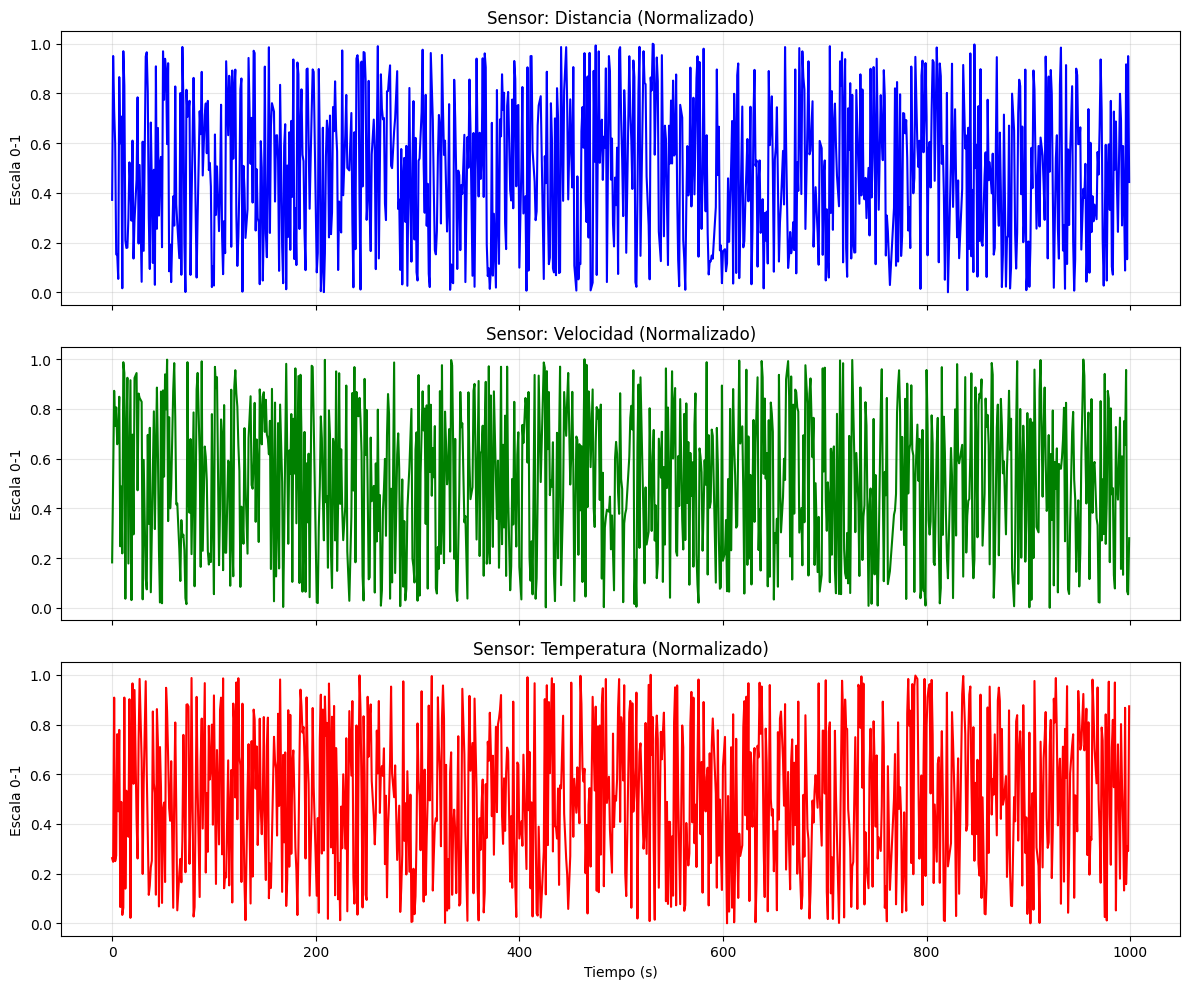

In [ ]:
#Celda 6 Sección para generar gráficas individuales (subplots)
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)  # Crea 3 filas de gráficas que comparten el eje X

axs[0].plot(df_norm['Tiempo (s)'], df_norm['Distancia (cm)'], color='b')  # Grafica Distancia en la primera fila
axs[0].set_title('Sensor: Distancia (Normalizado)')  # Título de la primera gráfica
axs[0].set_ylabel('Escala 0-1')  # Etiqueta vertical
axs[0].grid(True, alpha=0.3)  # Cuadrícula tenue

axs[1].plot(df_norm['Tiempo (s)'], df_norm['Velocidad (cm/s)'], color='g')  # Grafica Velocidad en la segunda fila
axs[1].set_title('Sensor: Velocidad (Normalizado)')  # Título de la segunda gráfica
axs[1].set_ylabel('Escala 0-1')  # Etiqueta vertical
axs[1].grid(True, alpha=0.3)  # Cuadrícula tenue

axs[2].plot(df_norm['Tiempo (s)'], df_norm['Temperatura (°C)'], color='r')  # Grafica Temperatura en la tercera fila
axs[2].set_title('Sensor: Temperatura (Normalizado)')  # Título de la tercera gráfica
axs[2].set_ylabel('Escala 0-1')  # Etiqueta vertical
axs[2].set_xlabel('Tiempo (s)')  # Etiqueta de tiempo solo en la gráfica de abajo
axs[2].grid(True, alpha=0.3)  # Cuadrícula tenue

plt.tight_layout()  # Ajusta automáticamente el espacio para que no se encimen los títulos
plt.show()  # Despliega las tres gráficas de forma ordenada

In [ ]:
#Celda 7 Resumen estadístico de los sensores
print("--- Estadísticas descriptivas (Datos Normalizados) ---")  # Título de sección
# El método describe() calcula automáticamente media, desviación, cuartiles, etc.
print(df_norm[cols].describe())  # Muestra el análisis estadístico en consola

--- Estadísticas descriptivas (Datos Normalizados) ---
       Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
count      913.000000        913.000000        913.000000
mean         0.487539          0.505184          0.503690
std          0.295048          0.293581          0.292465
min          0.000000          0.000000          0.000000
25%          0.225273          0.238892          0.260847
50%          0.499338          0.518528          0.504177
75%          0.739772          0.760704          0.762667
max          1.000000          1.000000          1.000000


In [ ]:
#Celda 8 Análisis de relación entre sensores
print("--- Matriz de Correlación ---")  # Título informativo
# La correlación indica qué tanto se parecen los cambios de un sensor con otro
print(df_norm[cols].corr())  # Muestra la relación matemática entre variables

--- Matriz de Correlación ---
                  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
Distancia (cm)          1.000000          0.032369          0.019119
Velocidad (cm/s)        0.032369          1.000000          0.028204
Temperatura (°C)        0.019119          0.028204          1.000000
